# Phase 4 : Approche Semi-Supervisée
Ce notebook implémente une approche de **Pseudo-Labeling (Self-Training)** pour améliorer les performances du modèle de classification en utilisant les données non labellisées.

**Objectifs :**
1. Charger les embeddings ResNet50.
2. Établir une baseline supervisée avec les 100 labels disponibles.
3. Utiliser les 1406 images non labellisées pour étendre le dataset via pseudo-labeling.
4. Évaluer le gain de performance.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

## 1. Chargement des Données
Nous chargeons les embeddings extraits lors de la phase 2.

In [2]:
# Charger les données
features_path = "../data/features_brainscan.npy"
data = np.load(features_path, allow_pickle=True).item()

X = data["features"]
filenames = data["filenames"]
labels_raw = data["labels"]

print(f"Total samples: {len(X)}")
print(f"Feature dimension: {X.shape[1]}")

# Répartition initiale
unique, counts = np.unique(labels_raw, return_counts=True)
print("Répartition labels:", dict(zip(unique, counts)))

Total samples: 1506
Feature dimension: 2048
Répartition labels: {'Cancer': 50, 'Normal': 50, 'non_labellise': 1406}


## 2. Préparation des données
Nous séparons les données labellisées des données non labellisées.

> **Note** : Le fichier `.npy` contient les labels tels que sauvegardés par le notebook 02 (`Normal`, `Cancer`, `non_labellise`). On mappe dynamiquement ci-dessous.

In [3]:
# Détection automatique des labels labellisés vs non labellisés
UNLABELED_TAGS = {'non_labellise', 'sans_label'}

# Construire le mapping dynamiquement
labeled_classes = sorted([l for l in np.unique(labels_raw) if l.lower() not in UNLABELED_TAGS])
label_map = {cls: i for i, cls in enumerate(labeled_classes)}
# Unlabeled -> -1
for tag in UNLABELED_TAGS:
    label_map[tag] = -1

print("Mapping des labels:", label_map)

y = np.array([label_map.get(l, -1) for l in labels_raw])

idx_labeled = np.where(y != -1)[0]
idx_unlabeled = np.where(y == -1)[0]

print(f"\nDonnées labellisées  : {len(idx_labeled)}")
print(f"Données non labellisées : {len(idx_unlabeled)}")

X_labeled = X[idx_labeled]
y_labeled = y[idx_labeled]

X_train_lab, X_test, y_train_lab, y_test = train_test_split(
    X_labeled, y_labeled, test_size=0.2, random_state=42, stratify=y_labeled
)

scaler = StandardScaler()
X_train_lab_scaled = scaler.fit_transform(X_train_lab)
X_test_scaled = scaler.transform(X_test)
X_unlabeled_scaled = scaler.transform(X[idx_unlabeled])

print(f"\nTrain (labellisé) : {len(X_train_lab_scaled)}")
print(f"Test              : {len(X_test_scaled)}")

Mapping des labels: {'Cancer': 0, 'Normal': 1, 'non_labellise': -1, 'sans_label': -1}

Données labellisées  : 100
Données non labellisées : 1406

Train (labellisé) : 80
Test              : 20


## 3. Baseline Supervisée
Entraînement d'une régression logistique uniquement sur les données labellisées.

In [4]:
target_names = labeled_classes

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_lab_scaled, y_train_lab)
y_pred_baseline = baseline_model.predict(X_test_scaled)

print("--- Baseline Supervisée : Classification Report ---")
print(classification_report(y_test, y_pred_baseline, target_names=target_names))
baseline_acc = accuracy_score(y_test, y_pred_baseline)
print(f"Accuracy Baseline : {baseline_acc:.4f}")

--- Baseline Supervisée : Classification Report ---
              precision    recall  f1-score   support

      Cancer       0.82      0.90      0.86        10
      Normal       0.89      0.80      0.84        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20

Accuracy Baseline : 0.8500


## 4. Approche Semi-Supervisée (Self-Training)
On combine les données labellisées (labels réels) et non labellisées (labels = -1) pour l'entraînement avec `SelfTrainingClassifier`.

In [5]:
X_comb = np.vstack([X_train_lab_scaled, X_unlabeled_scaled])
y_comb = np.concatenate([y_train_lab, np.full(len(X_unlabeled_scaled), -1)])

# SelfTrainingClassifier nécessite un estimateur avec predict_proba
# LogisticRegression fournit predict_proba nativement
base_lr = LogisticRegression(max_iter=1000, random_state=42)
st_model = SelfTrainingClassifier(base_lr, threshold=0.8, max_iter=10, verbose=True)
st_model.fit(X_comb, y_comb)

y_pred_st = st_model.predict(X_test_scaled)
print("\n--- Semi-Supervisé : Classification Report ---")
print(classification_report(y_test, y_pred_st, target_names=target_names))
st_acc = accuracy_score(y_test, y_pred_st)
print(f"Accuracy Semi-Supervisé : {st_acc:.4f}")
print(f"Gain vs Baseline        : {st_acc - baseline_acc:+.4f}")

End of iteration 1, added 1306 new labels.
End of iteration 2, added 51 new labels.
End of iteration 3, added 29 new labels.
End of iteration 4, added 9 new labels.
End of iteration 5, added 1 new labels.
End of iteration 6, added 1 new labels.

--- Semi-Supervisé : Classification Report ---
              precision    recall  f1-score   support

      Cancer       0.82      0.90      0.86        10
      Normal       0.89      0.80      0.84        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20

Accuracy Semi-Supervisé : 0.8500
Gain vs Baseline        : +0.0000


## 5. Visualisation Comparative

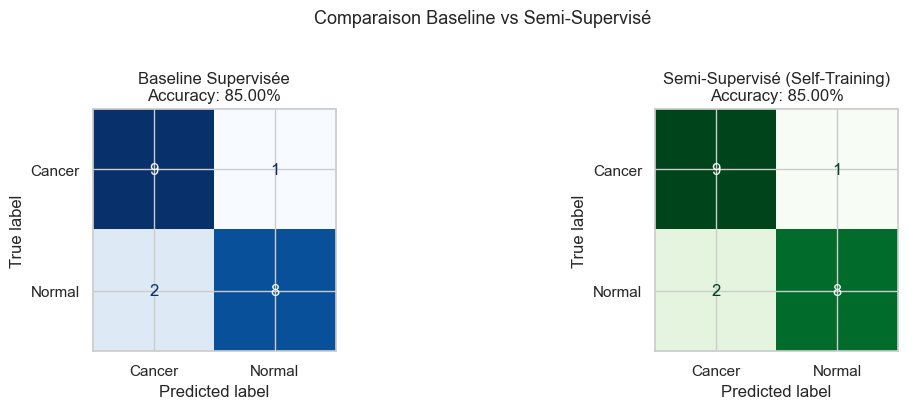

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Baseline
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
ConfusionMatrixDisplay(cm_baseline, display_labels=target_names).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f"Baseline Supervisée\nAccuracy: {baseline_acc:.2%}")

# Semi-Supervisé
cm_st = confusion_matrix(y_test, y_pred_st)
ConfusionMatrixDisplay(cm_st, display_labels=target_names).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f"Semi-Supervisé (Self-Training)\nAccuracy: {st_acc:.2%}")

plt.suptitle("Comparaison Baseline vs Semi-Supervisé", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Récapitulatif des métriques
results = pd.DataFrame({
    "Méthode": ["Baseline Supervisée", "Semi-Supervisée (Self-Training)"],
    "Accuracy": [baseline_acc, st_acc],
    "Gain": [0, st_acc - baseline_acc]
})
print(results.to_string(index=False))

                        Méthode  Accuracy  Gain
            Baseline Supervisée      0.85   0.0
Semi-Supervisée (Self-Training)      0.85   0.0
